In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df=pd.read_csv('./data/audio_products_final.csv')

In [4]:
df.shape

(518, 27)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                518 non-null    str    
 1   category             518 non-null    str    
 2   sale_price           518 non-null    float64
 3   mrp                  518 non-null    float64
 4   discount_percent     518 non-null    float64
 5   num_variants         518 non-null    float64
 6   edition_type         518 non-null    str    
 7   model_series         518 non-null    str    
 8   year                 516 non-null    float64
 9   month                516 non-null    float64
 10  color_count          518 non-null    float64
 11  driver_size_mm       517 non-null    float64
 12  product_id           518 non-null    float64
 13  playback_per_charge  518 non-null    float64
 14  bluetooth            518 non-null    float64
 15  anc_db               86 non-null     float64
 16  h

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['brand'].value_counts()

brand
boAt     390
Noise    128
Name: count, dtype: int64

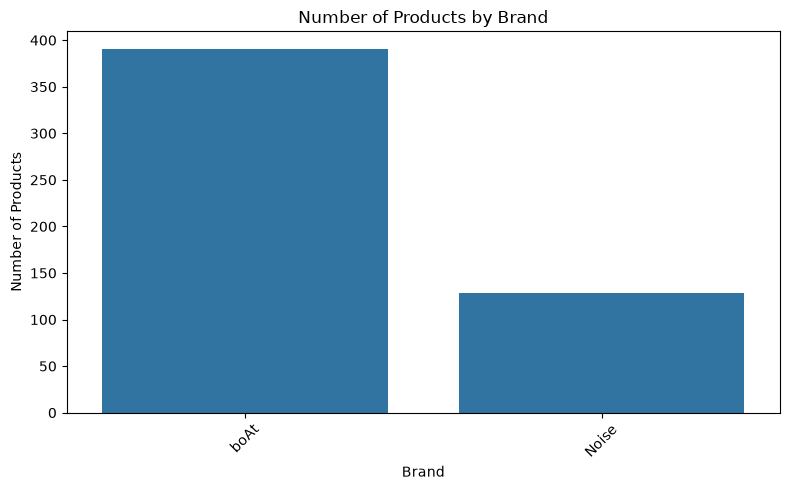

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='brand',
    order=df['brand'].value_counts().index
)

plt.title('Number of Products by Brand')
plt.xlabel('Brand')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

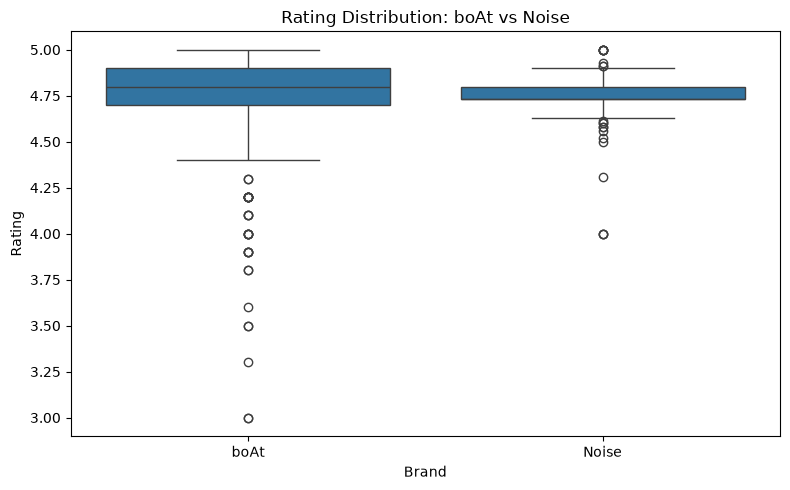

In [65]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='brand',
    y='rating'
)

plt.title('Rating Distribution: boAt vs Noise')
plt.xlabel('Brand')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

In [10]:
df['rating'] = df['rating'].fillna(
    df.groupby(['category', 'model_series'])['rating']
      .transform('median')
)

In [11]:
df['rating'] = df['rating'].fillna(df['rating'].median())

In [12]:
df['rating'].isna().sum()

np.int64(0)

In [13]:
df.columns

Index(['brand', 'category', 'sale_price', 'mrp', 'discount_percent',
       'num_variants', 'edition_type', 'model_series', 'year', 'month',
       'color_count', 'driver_size_mm', 'product_id', 'playback_per_charge',
       'bluetooth', 'anc_db', 'has_anc', 'has_enc', 'playtime', 'ip_rating',
       'latency', 'fast_charge', 'connectivity', 'gaming_mode', 'rating',
       'battery_capacity', 'base_model'],
      dtype='str')

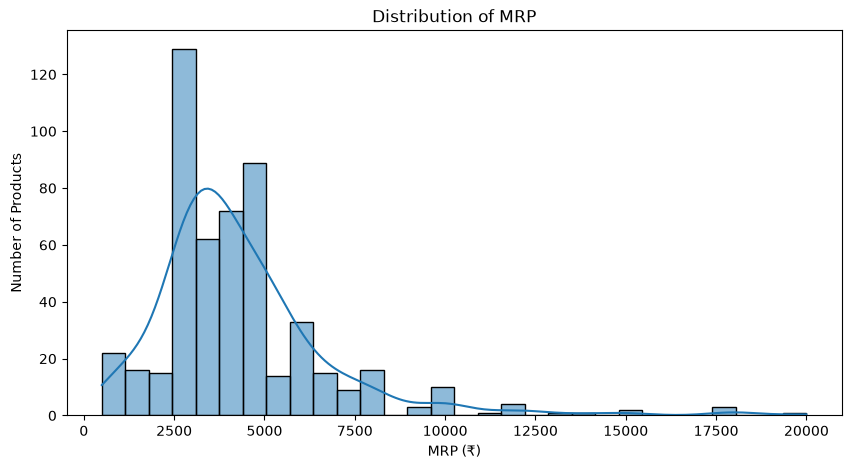

In [66]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='mrp',
    bins=30,
    kde=True
)

plt.title('Distribution of MRP')
plt.xlabel('MRP (₹)')
plt.ylabel('Number of Products')

plt.show()

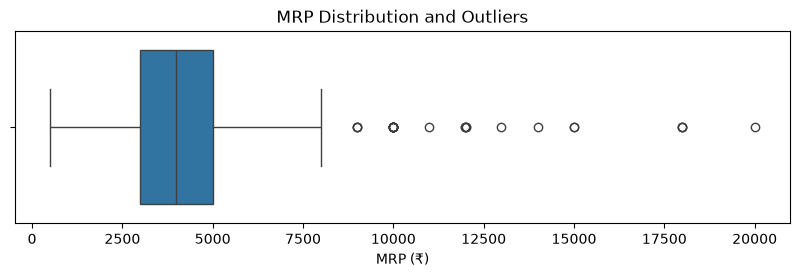

In [68]:
plt.figure(figsize=(10, 2.5))

sns.boxplot(
    data=df,
    x='mrp'
)

plt.title('MRP Distribution and Outliers')
plt.xlabel('MRP (₹)')

plt.show()

In [16]:
Q1 = df['mrp'].quantile(0.25)
Q3 = df['mrp'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df[df['mrp'] > upper][['brand', 'category','base_model', 'model_series', 'mrp']]

,brand,category,base_model,model_series,mrp
76,boAt,True Wireless Earbuds,airdopes 500 anc,Airdopes,9999.0
77,boAt,True Wireless Earbuds,airdopes 501 anc,Airdopes,9990.0
79,boAt,True Wireless Earbuds,airdopes 601 anc,Airdopes,9990.0
83,boAt,True Wireless Earbuds,airdopes 711,Airdopes,11990.0
216,boAt,Headphones,immortal 1300,Immortal,9990.0
219,boAt,True Wireless Earbuds,nirvana ion anc,Nirvana,11999.0
221,boAt,True Wireless Earbuds,nirvana lucid,Nirvana,9999.0
223,boAt,True Wireless Earbuds,nirvana zenith pro,Nirvana,14990.0
286,boAt,Headphones,nirvana 1007 anc,Nirvana,19999.0
291,boAt,True Wireless Earbuds,nirvana crown tws,Nirvana,9990.0


<Axes: xlabel='sale_price'>

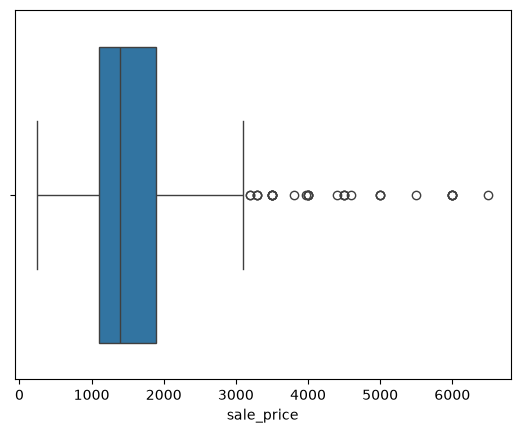

In [17]:
sns.boxplot(data=df,x='sale_price')

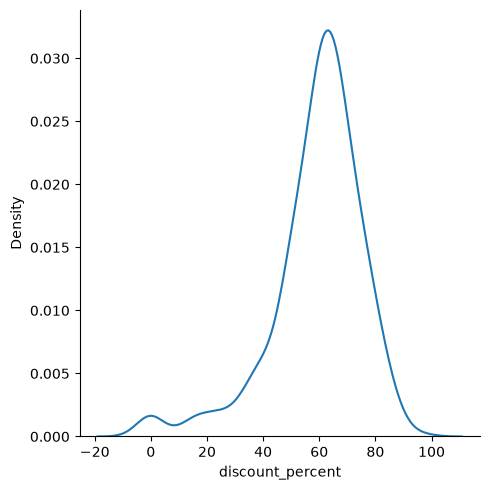

In [33]:
sns.displot(data=df,x='discount_percent',kind='kde')

<Axes: xlabel='num_variants', ylabel='count'>

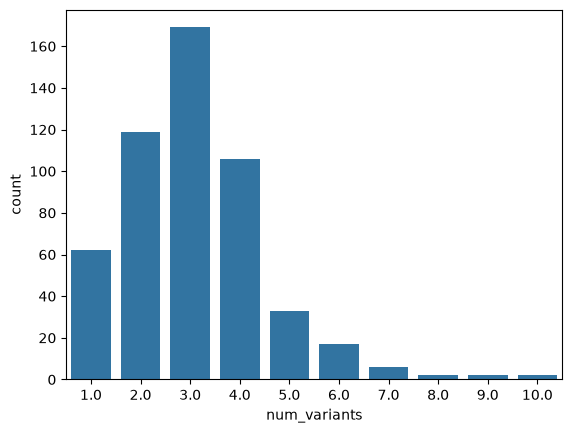

In [69]:
sns.countplot(data=df,x='num_variants')

In [38]:
df[df['num_variants']==10]

,brand,category,sale_price,mrp,discount_percent,num_variants,edition_type,model_series,year,month,...,has_enc,playtime,ip_rating,latency,fast_charge,connectivity,gaming_mode,rating,battery_capacity,base_model
25,boAt,True Wireless Earbuds,799.0,4490.0,82.20,10.0,Standard,Airdopes,2022.0,2.0,...,True,42.0,IPX4,80.0,True,Dual,True,4.8,600.0,airdopes 141
32,boAt,True Wireless Earbuds,999.0,2490.0,59.88,10.0,Standard,Airdopes,2022.0,9.0,...,False,40.0,IPX5,NaN,True,NaN,False,4.8,300.0,airdopes 161


In [18]:
df.loc[[13,164,295],'num_variants']=[3,3,1]

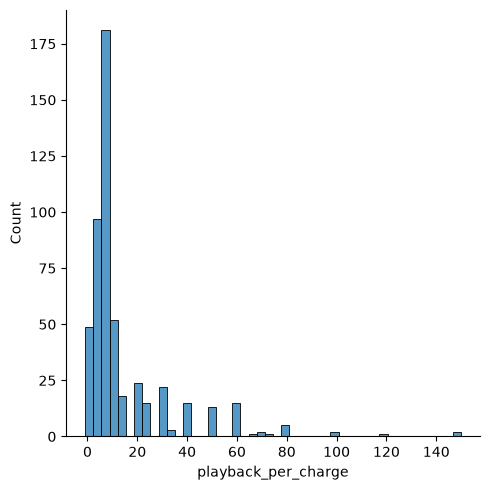

In [70]:
sns.displot(data=df,x='playback_per_charge')

<Axes: xlabel='playback_per_charge'>

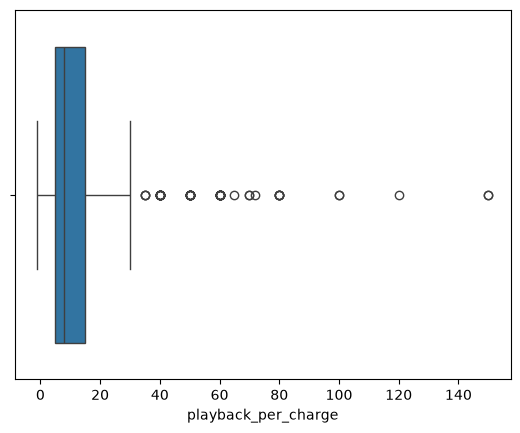

In [71]:
sns.boxplot(data=df,x='playback_per_charge')

In [52]:
df[df['playback_per_charge']>=80][['base_model','playback_per_charge']]

,base_model,playback_per_charge
245,rockerz 512 anc,80.0
251,rockerz plus 450 anc,80.0
254,rockerz prime 415,120.0
257,rockerz trinity grande,150.0
429,xtreme,100.0
452,rockerz 255 anc,100.0
504,rockerz 650 pro,80.0
507,rockerz 80 pro,80.0
511,rockerz plus 550 anc,80.0
514,rockerz trinity gen 2,150.0


In [72]:
df.loc[[203,223,292,293,295,296,297,299,306,252,327,328,330,409],'playback_per_charge']=[10,8,8,20,24,24,24,8,8,20,8,8,8,7]

<Axes: xlabel='bluetooth', ylabel='count'>

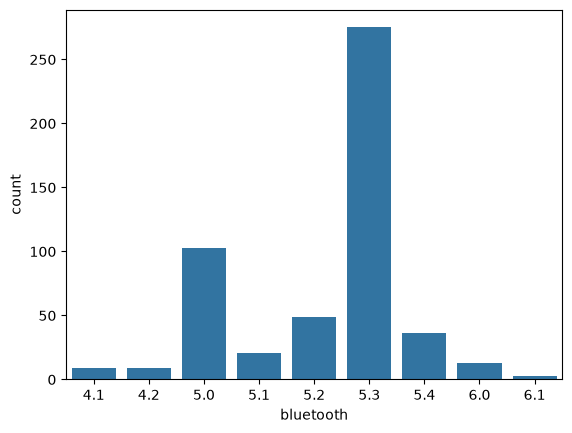

In [73]:
sns.countplot(data=df,x='bluetooth')

In [20]:
import numpy as np
df.loc[df['bluetooth']==-1,'bluetooth']=np.nan

In [57]:
df['bluetooth'].value_counts()

bluetooth
5.3    221
5.0    103
5.2     49
5.4     36
5.1     21
6.0     13
4.2      9
4.1      9
6.1      3
Name: count, dtype: int64

<Axes: xlabel='has_anc', ylabel='count'>

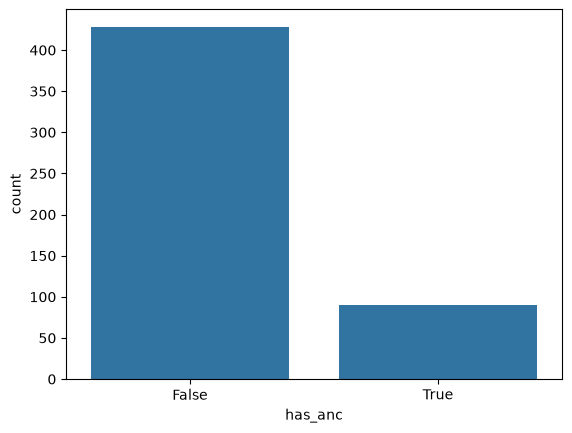

In [60]:
sns.countplot(data=df,x='has_anc')

<Axes: xlabel='has_enc', ylabel='count'>

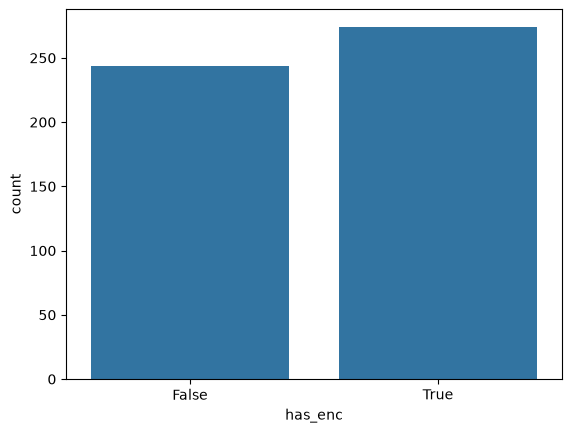

In [61]:
sns.countplot(data=df,x='has_enc')

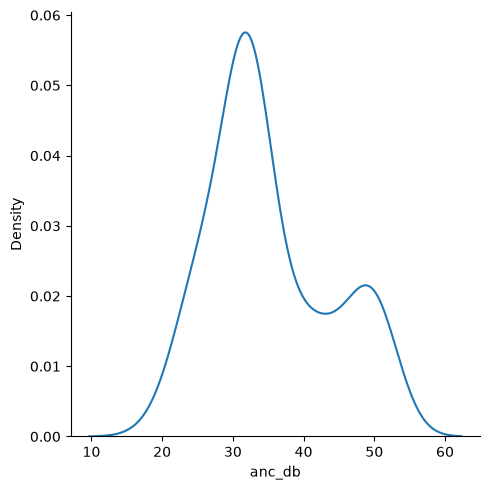

In [65]:
sns.displot(data=df,x='anc_db',kind='kde')

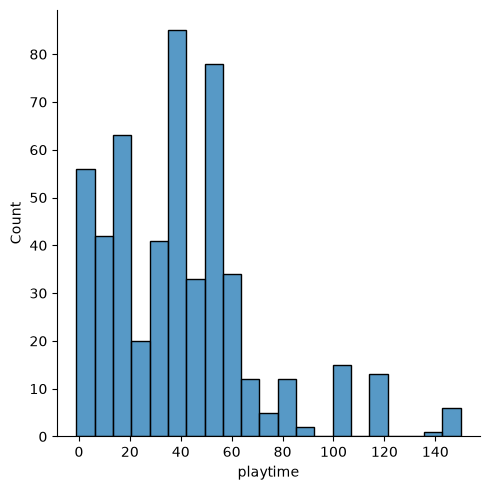

In [74]:
sns.displot(data=df,x='playtime')

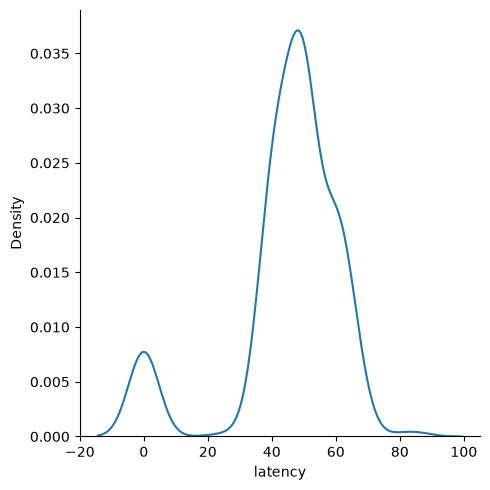

In [75]:
sns.displot(data=df,x='latency',kind='kde')

In [82]:
df['latency'].value_counts(dropna=False)

latency
NaN     305
40.0     51
0.0      48
50.0     42
65.0     27
60.0     22
45.0     13
35.0      3
55.0      2
85.0      2
80.0      1
30.0      1
24.0      1
Name: count, dtype: int64

In [21]:
df.loc[[5,448],'latency']=[50,40]

In [ ]:
pd.crosstab(df['latency'].isna(), df['category'])

category,Headphone,Headphones,Neckband,True Wireless Earbuds,Wired Earphones,Wired Headphones
latency,,,,,,
False,3,16,38,107,43,6
True,3,50,62,190,0,0


In [84]:
pd.crosstab(df['latency'].isna(), df['gaming_mode'].fillna(False))


gaming_mode,False,True
latency,,
False,85,128
True,227,78


<Axes: xlabel='fast_charge'>

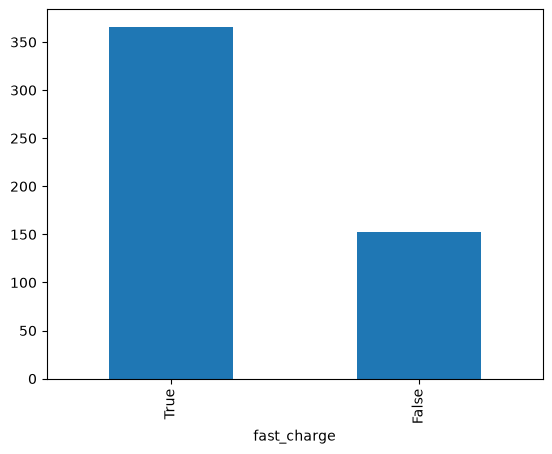

In [90]:
df['fast_charge'].value_counts().plot(kind='bar')


In [95]:
df['latency'].isna().sum()

np.int64(305)

In [22]:
remaining_missing = df[(df['latency'].isna()) & (~df['category'].isin(['Wired Earphones', 'Wired Headphones']))]
print(len(remaining_missing))
remaining_missing['category'].value_counts()

305


category
True Wireless Earbuds    190
Neckband                  62
Headphones                50
Headphone                  3
Name: count, dtype: int64

In [27]:
df['category'].value_counts()

category
True Wireless Earbuds    299
Neckband                 100
Headphones                70
Wired Earphones           43
Wired Headphones           6
Name: count, dtype: int64

In [104]:
df['connectivity'].isna().sum()

np.int64(0)

In [23]:
df.loc[[247,293,413,481],'category']='Headphones'
df.loc[[327,328],'category']='True Wireless Earbuds'

In [24]:
df['connectivity'] = df['connectivity'].fillna('Single')

In [25]:
df.loc[df['category']=='Wired Earphones','battery_capacity']=-1

In [28]:
def price_tier(price):
    if pd.isna(price):
        return None
    elif price <= 1500:
        return 'Budget'
    elif price <= 3000:
        return 'Mid'
    else:
        return 'High'

df['price_tier'] = df['sale_price'].apply(price_tier)

df['price_tier'].value_counts()

price_tier
Budget    312
Mid       170
High       36
Name: count, dtype: int64

In [112]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                518 non-null    str    
 1   category             518 non-null    str    
 2   sale_price           518 non-null    float64
 3   mrp                  518 non-null    float64
 4   discount_percent     518 non-null    float64
 5   num_variants         518 non-null    float64
 6   edition_type         518 non-null    str    
 7   model_series         518 non-null    str    
 8   year                 516 non-null    float64
 9   month                516 non-null    float64
 10  color_count          518 non-null    float64
 11  driver_size_mm       517 non-null    float64
 12  product_id           518 non-null    float64
 13  playback_per_charge  518 non-null    float64
 14  bluetooth            464 non-null    float64
 15  anc_db               86 non-null     float64
 16  h

In [114]:
df[['latency', 'battery_capacity','mrp','num_variants','color_count','driver_size_mm','playback_per_charge','playtime','rating']].corr()

,latency,battery_capacity,mrp,num_variants,color_count,driver_size_mm,playback_per_charge,playtime,rating
latency,1.000000,0.743582,0.620248,0.115194,0.120206,0.000545,0.408833,0.630848,-0.004726
battery_capacity,0.743582,1.000000,0.403667,-0.072512,-0.021638,0.114243,0.185988,0.521479,0.017119
mrp,0.620248,0.403667,1.000000,-0.044623,-0.017517,0.086790,0.114986,0.397490,-0.142125
num_variants,0.115194,-0.072512,-0.044623,1.000000,0.844411,-0.116806,-0.019149,0.003960,0.083480
color_count,0.120206,-0.021638,-0.017517,0.844411,1.000000,-0.113089,-0.028020,0.067601,0.075205
driver_size_mm,0.000545,0.114243,0.086790,-0.116806,-0.113089,1.000000,0.234938,0.059394,-0.013529
playback_per_charge,0.408833,0.185988,0.114986,-0.019149,-0.028020,0.234938,1.000000,0.398019,-0.035553
playtime,0.630848,0.521479,0.397490,0.003960,0.067601,0.059394,0.398019,1.000000,-0.155780
rating,-0.004726,0.017119,-0.142125,0.083480,0.075205,-0.013529,-0.035553,-0.155780,1.000000


In [116]:
!pip install scikit-learn


  Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl (8.4 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl (37.4 MB)
Using cached threadpoolctl-3.7.0-py3-none-any.whl (26 kB)

   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- -------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
df['battery_capacity'] = df['battery_capacity'].fillna(
    df.groupby(
        ['price_tier', 'category', 'model_series']
    )['battery_capacity'].transform('median')
)

In [30]:
df['battery_capacity'].isna().sum()

np.int64(23)

In [31]:
df['battery_capacity'] = df['battery_capacity'].fillna(
    df.groupby(['price_tier', 'category'])['battery_capacity']
      .transform('median')
)

df['battery_capacity'] = df['battery_capacity'].fillna(
    df.groupby('price_tier')['battery_capacity']
      .transform('median')
)

df['battery_capacity'] = df['battery_capacity'].fillna(
    df['battery_capacity'].median()
)

print(df['battery_capacity'].isna().sum())

0


In [121]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                518 non-null    str    
 1   category             518 non-null    str    
 2   sale_price           518 non-null    float64
 3   mrp                  518 non-null    float64
 4   discount_percent     518 non-null    float64
 5   num_variants         518 non-null    float64
 6   edition_type         518 non-null    str    
 7   model_series         518 non-null    str    
 8   year                 516 non-null    float64
 9   month                516 non-null    float64
 10  color_count          518 non-null    float64
 11  driver_size_mm       517 non-null    float64
 12  product_id           518 non-null    float64
 13  playback_per_charge  518 non-null    float64
 14  bluetooth            464 non-null    float64
 15  anc_db               86 non-null     float64
 16  h

In [125]:
df[df['year'].isna()]

,brand,category,sale_price,mrp,discount_percent,num_variants,edition_type,model_series,year,month,...,playtime,ip_rating,latency,fast_charge,connectivity,gaming_mode,rating,battery_capacity,base_model,price_tier
404,Noise,Wired Earphones,499.0,999.0,50.05,2.0,Standard,Chord,NaN,NaN,...,-1.0,NaN,0.0,False,Single,False,4.8,-1.0,chord 100 type c,Budget
405,Noise,Wired Earphones,599.0,999.0,40.04,2.0,Standard,Chord,NaN,NaN,...,-1.0,NaN,0.0,False,Single,False,4.8,-1.0,chord 200 type c,Budget


In [32]:
df.loc[425,'driver_size_mm']=10

In [33]:
df.loc[404,'year']=2026
df.loc[404,'month']=7
df.loc[405,'year']=2026
df.loc[405,'month']=7

In [34]:
df['playtime'] = df['playtime'].fillna(
    df.groupby(
        ['price_tier', 'category', 'model_series']
    )['playtime'].transform('median')
)

In [134]:
df['playtime'].isna().sum()

np.int64(6)

In [37]:
df['playtime'] = df['playtime'].fillna(
    df.groupby(['price_tier', 'category'])['playtime']
      .transform('median')
)

In [36]:
df['playtime'] = df['playtime'].fillna(
    df.groupby('category')['playtime']
      .transform('median')
)

In [38]:
df['playtime'] = df['playtime'].fillna(df['playtime'].median())

In [39]:
df['bluetooth'].isna().sum()

np.int64(54)

In [40]:
df['bluetooth'] = df['bluetooth'].fillna(
    df.groupby(['price_tier', 'category', 'model_series'])['bluetooth']
      .transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

In [41]:
df['bluetooth'] = df['bluetooth'].fillna(
    df.groupby(['price_tier', 'category'])['bluetooth']
      .transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

In [42]:
df['bluetooth'] = df['bluetooth'].fillna(
    df['bluetooth'].mode()[0]
)

In [155]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                518 non-null    str    
 1   category             518 non-null    str    
 2   sale_price           518 non-null    float64
 3   mrp                  518 non-null    float64
 4   discount_percent     518 non-null    float64
 5   num_variants         518 non-null    float64
 6   edition_type         518 non-null    str    
 7   model_series         518 non-null    str    
 8   year                 518 non-null    float64
 9   month                518 non-null    float64
 10  color_count          518 non-null    float64
 11  driver_size_mm       518 non-null    float64
 12  product_id           518 non-null    float64
 13  playback_per_charge  518 non-null    float64
 14  bluetooth            518 non-null    float64
 15  anc_db               86 non-null     float64
 16  h

In [43]:
df['latency'] = df['latency'].fillna(
    df.groupby(
        ['price_tier', 'category', 'model_series']
    )['latency'].transform('median')
)

In [44]:
df['latency'] = df['latency'].fillna(
    df.groupby(['price_tier', 'category'])['latency']
      .transform('median')
)

In [46]:
df[df['category']=='Neckband']['latency'].max()

np.float64(65.0)

In [156]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                518 non-null    str    
 1   category             518 non-null    str    
 2   sale_price           518 non-null    float64
 3   mrp                  518 non-null    float64
 4   discount_percent     518 non-null    float64
 5   num_variants         518 non-null    float64
 6   edition_type         518 non-null    str    
 7   model_series         518 non-null    str    
 8   year                 518 non-null    float64
 9   month                518 non-null    float64
 10  color_count          518 non-null    float64
 11  driver_size_mm       518 non-null    float64
 12  product_id           518 non-null    float64
 13  playback_per_charge  518 non-null    float64
 14  bluetooth            518 non-null    float64
 15  anc_db               86 non-null     float64
 16  h

<Axes: xlabel='count', ylabel='category'>

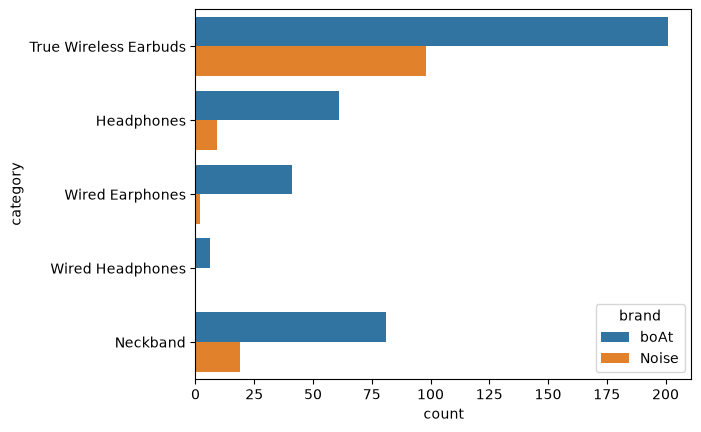

In [76]:
sns.countplot(
    data=df,
    y='category',
    hue='brand'
)

In [77]:
fig = px.histogram(
    df,
    x='sale_price',
    color='brand',
    nbins=30,
    marginal='box',
    barmode='overlay',
    title='Sale Price Distribution by Brand'
)

fig.show()

In [78]:
fig = px.box(
    df,
    x='brand',
    y='sale_price',
    color='brand',
    points='outliers',
    title='Sale Price Distribution by Brand'
)

fig.show()

In [79]:
fig = px.scatter(
    df,
    x='mrp',
    y='sale_price',
    color='brand',
    hover_data=['base_model', 'category', 'discount_percent'],
    title='MRP vs Sale Price'
)

fig.show()

In [80]:
px.histogram(
    df,
    x='discount_percent',
    color='brand',
    nbins=25,
    marginal='box',
    title='Discount Percentage Distribution'
)

In [162]:
fig = px.box(
    df,
    x='brand',
    y='discount_percent',
    color='brand',
    points='outliers',
    title='Discount Percentage by Brand'
)

fig.show()

In [81]:
fig = px.histogram(
    df,
    x='price_tier',
    color='brand',
    barmode='group',
    title='Price Tier Distribution by Brand'
)

fig.show()

In [82]:
fig = px.box(
    df,
    x='brand',
    y='rating',
    color='brand',
    points='outliers',

    title='Product Ratings by Brand'
)

fig.update_yaxes(
    range=[3.5, 5.0],
    dtick=0.25,
    title='Rating'
)

fig.show()

In [83]:
fig = px.scatter(
    df,
    x='sale_price',
    y='playback_per_charge',
    color='brand',
    hover_name='base_model',
    hover_data=[
        'category',
        'mrp',
        'discount_percent',
        'rating'
    ],
    title='Sale Price vs Playback Time'
)

fig.update_layout(
    xaxis_title='Sale Price (₹)',
    yaxis_title='Playback Time (hours)'
)

fig.show()

In [84]:
fig = px.strip(
    df,
    x='price_tier',
    y='playback_per_charge',
    color='brand',
    title='Playback Time Across Price Tiers'
)

fig.show()

In [86]:
median_playback = (
    df.groupby(['price_tier', 'brand'])['playback_per_charge']
      .median()
      .reset_index()
)


In [87]:
px.bar(
    median_playback,
    x='price_tier',
    y='playback_per_charge',
    color='brand',
    barmode='group',
    text_auto=True,
    title='Median Playback Time by Price Tier'
)

In [88]:
median_playback = (
    df.groupby(['price_tier', 'brand'])['playback_per_charge']
      .mean()
      .reset_index()
)
px.bar(
    median_playback,
    x='price_tier',
    y='playback_per_charge',
    color='brand',
    barmode='group',
    text_auto=True,
    title='Mean Playback Time by Price Tier'
)

In [197]:
fig = px.scatter(
    df,
    x='battery_capacity',
    y='sale_price',
    color='brand',
    hover_name='base_model',
    hover_data=[
        'category',
        'mrp',
        'discount_percent',
        'playback_per_charge',
        'rating'
    ],
    title='Battery Capacity vs Sale Price'
)

fig.update_layout(
    xaxis_title='Battery Capacity (mAh)',
    yaxis_title='Sale Price (₹)'
)
fig.update_xaxes(range=[2,1100])

fig.show()

In [89]:
battery_brand = (
    df.groupby(['brand','price_tier'])['battery_capacity']
      .median()
      .reset_index()
)

fig = px.bar(
    battery_brand,
    x='price_tier',
    y='battery_capacity',
    color='brand',
    text='battery_capacity',
    barmode='group',
    title='Median Battery Capacity by Brand'
)

fig.update_layout(
    xaxis_title='Brand',
    yaxis_title='Median Battery Capacity (mAh)'
)

fig.show()

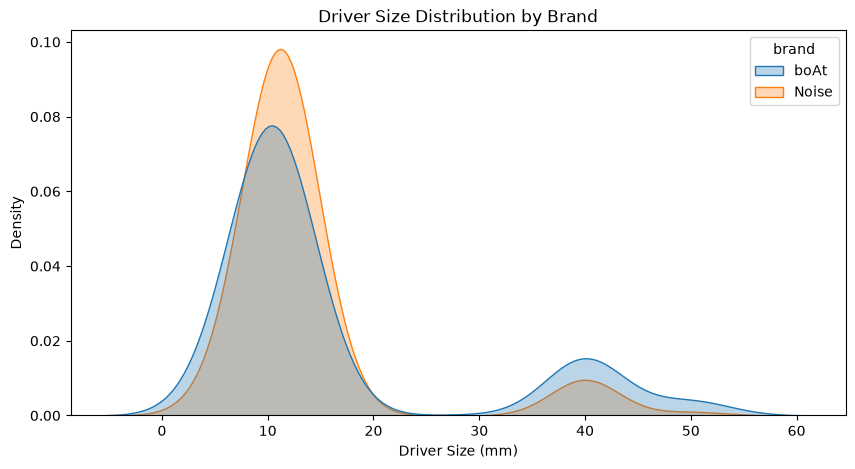

In [90]:
plt.figure(figsize=(10, 5))

sns.kdeplot(
    data=df,
    x='driver_size_mm',
    hue='brand',
    fill=True,
    common_norm=False,
    alpha=0.3
)

plt.xlabel('Driver Size (mm)')
plt.ylabel('Density')
plt.title('Driver Size Distribution by Brand')
plt.show()

In [93]:
feature_cols = ['has_anc', 'has_enc', 'gaming_mode', 'fast_charge']

feature_brands = (
    df.groupby('brand')[feature_cols]
      .mean()
      .reset_index()
)
feature_brands

,brand,has_anc,has_enc,gaming_mode,fast_charge
0,Noise,0.250000,0.617188,0.273438,0.835938
1,boAt,0.148718,0.500000,0.438462,0.664103


In [94]:
feature_brand = feature_brands.melt(
    id_vars='brand',
    var_name='feature',
    value_name='percentage'
)
feature_brand

,brand,feature,percentage
0,Noise,has_anc,0.250000
1,boAt,has_anc,0.148718
2,Noise,has_enc,0.617188
3,boAt,has_enc,0.500000
4,Noise,gaming_mode,0.273438
5,boAt,gaming_mode,0.438462
6,Noise,fast_charge,0.835938
7,boAt,fast_charge,0.664103


In [95]:
feature_brand['percentage'] *= 100

fig = px.bar(
    feature_brand,
    x='feature',
    y='percentage',
    color='brand',
    barmode='group',
    text_auto='.1f',
    title='Feature Adoption by Brand'
)

fig.update_layout(
    xaxis_title='Feature',
    yaxis_title='Products with Feature (%)'
)

fig.show()

In [213]:
fig = px.scatter(
    df,
    x='discount_percent',
    y='rating',
    color='brand',
    hover_name='base_model',
    hover_data=['category', 'sale_price', 'mrp'],
    title='Discount Percentage vs Product Rating'
)

fig.update_layout(
    xaxis_title='Discount (%)',
    yaxis_title='Rating'
)

fig.show()

In [96]:
fig = px.scatter(
    df,
    x='sale_price',
    y='rating',
    color='brand',
    hover_name='base_model',
    hover_data=['category', 'mrp', 'discount_percent'],
    title='Sale Price vs Product Rating'
)

fig.update_layout(
    xaxis_title='Sale Price (₹)',
    yaxis_title='Rating'
)

fig.show()

In [97]:
fig = px.box(
    df,
    x='price_tier',
    y='rating',
    color='brand',
    points=False,
    category_orders={
        'price_tier': ['Budget', 'Mid', 'High']
    },
    title='Product Ratings Across Price Tiers'
)

fig.update_layout(
    xaxis_title='Price Tier',
    yaxis_title='Rating'
)

fig.show()

In [98]:
playback_category = (
    df.groupby('category')['playback_per_charge']
      .median()
      .sort_values(ascending=False)
      .reset_index()
)
playback_category.drop(index=[3,4],inplace=True)
fig = px.bar(
    playback_category,
    x='playback_per_charge',
    y='category',
    orientation='h',
    text='playback_per_charge',
    title='Median Playback Time by Product Category'
)

fig.update_traces(texttemplate='%{text:.1f} hrs', textposition='outside')

fig.update_layout(
    xaxis_title='Median Playback Time (hours)',
    yaxis_title='Product Category'
)

fig.show()

In [99]:
playback_brand_tier = (
    df.groupby(['brand', 'price_tier'])['playback_per_charge']
      .median()
      .reset_index()
)

fig = px.bar(
    playback_brand_tier,
    x='price_tier',
    y='playback_per_charge',
    color='brand',
    barmode='group',
    text='playback_per_charge',
    category_orders={
        'price_tier': ['budget', 'mid', 'high']
    },
    title='Median Playback Time by Brand and Price Tier'
)

fig.update_traces(
    texttemplate='%{text:.1f} hrs',
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Price Tier',
    yaxis_title='Median Playback Time (hours)'
)

fig.show()

In [100]:
anc_brand_tier = (
    df.groupby(['brand', 'price_tier'])['has_anc']
      .mean()
      .reset_index()
)

anc_brand_tier['has_anc'] *= 100

fig = px.bar(
    anc_brand_tier,
    x='price_tier',
    y='has_anc',
    color='brand',
    barmode='group',
    text='has_anc',
    category_orders={
        'price_tier': ['budget', 'mid', 'high']
    },
    title='ANC Adoption by Brand and Price Tier'
)

fig.update_traces(
    texttemplate='%{text:.1f}%',
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Price Tier',
    yaxis_title='Products with ANC (%)'
)

fig.show()

In [101]:
enc_brand_tier = (
    df.groupby(['brand', 'price_tier'])['has_enc']
      .mean()
      .reset_index()
)

enc_brand_tier['has_enc'] *= 100

fig = px.bar(
    enc_brand_tier,
    x='price_tier',
    y='has_enc',
    color='brand',
    barmode='group',
    text='has_enc',
    category_orders={
        'price_tier': ['budget', 'mid', 'high']
    },
    title='ENC Adoption by Brand and Price Tier'
)

fig.update_traces(
    texttemplate='%{text:.1f}%',
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Price Tier',
    yaxis_title='Products with ENC (%)'
)

fig.show()

In [102]:
gaming_brand_tier = (
    df.groupby(['brand', 'price_tier'])['gaming_mode']
      .mean()
      .reset_index()
)

gaming_brand_tier['gaming_mode'] *= 100

fig = px.bar(
    gaming_brand_tier,
    x='price_tier',
    y='gaming_mode',
    color='brand',
    barmode='group',
    text='gaming_mode',
    category_orders={
        'price_tier': ['budget', 'mid', 'high']
    },
    title='Gaming Mode Adoption by Brand and Price Tier'
)

fig.update_traces(
    texttemplate='%{text:.1f}%',
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Price Tier',
    yaxis_title='Products with Gaming Mode (%)'
)

fig.show()

In [103]:
fig = px.box(
    df,
    x='gaming_mode',
    y='sale_price',
    color='gaming_mode',
    points=False,
    title='Sale Price Distribution by Gaming Mode'
)

fig.update_layout(
    xaxis_title='Gaming Mode',
    yaxis_title='Sale Price (₹)'
)

fig.update_xaxes(
    tickmode='array',
    tickvals=[False, True],
    ticktext=['No Gaming Mode', 'Gaming Mode']
)

fig.show()

In [104]:
fig = px.box(
    df,
    x='fast_charge',
    y='sale_price',
    color='fast_charge',
    points=False,
    title='Sale Price Distribution by Fast Charging'
)

fig.update_layout(
    xaxis_title='Fast Charging',
    yaxis_title='Sale Price (₹)'
)

fig.update_xaxes(
    tickmode='array',
    tickvals=[False, True],
    ticktext=['No Fast Charging', 'Fast Charging']
)

fig.show()

In [105]:
gaming_brand_category = (
    df.groupby(['brand', 'category'])['gaming_mode']
      .mean()
      .reset_index()
)
gaming_brand_category.drop(index=[3,7,8],inplace=True)
gaming_brand_category['gaming_mode'] *= 100

fig = px.bar(
    gaming_brand_category,
    x='category',
    y='gaming_mode',
    color='brand',
    barmode='group',
    text='gaming_mode',
    title='Gaming Mode Adoption by Brand and Category'
)

fig.update_traces(
    texttemplate='%{text:.1f}%',
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Product Category',
    yaxis_title='Products with Gaming Mode (%)'
)

fig.show()

In [235]:
gaming_brand_category

,brand,category,gaming_mode
0,Noise,Headphones,44.444444
1,Noise,Neckband,10.526316
2,Noise,True Wireless Earbuds,29.591837
3,Noise,Wired Earphones,0.000000
4,boAt,Headphones,29.508197
5,boAt,Neckband,55.555556
6,boAt,True Wireless Earbuds,53.731343
7,boAt,Wired Earphones,0.000000
8,boAt,Wired Headphones,0.000000


In [106]:
fast_brand_category = (
    df.groupby(['brand', 'category'])['fast_charge']
      .mean()
      .reset_index()
)
fast_brand_category.drop(index=[3,7,8],inplace=True)
fast_brand_category['fast_charge'] *= 100

fig = px.bar(
    fast_brand_category,
    x='category',
    y='fast_charge',
    color='brand',
    barmode='group',
    text='fast_charge',
    title='Fast Charging Adoption by Brand and Category'
)

fig.update_traces(
    texttemplate='%{text:.1f}%',
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Product Category',
    yaxis_title='Products with Fast Charging (%)'
)

fig.show()

In [107]:
discount_brand_category = (
    df.groupby(['brand', 'category'])['discount_percent']
      .mean()
      .reset_index()
)

fig = px.bar(
    discount_brand_category,
    x='category',
    y='discount_percent',
    color='brand',
    barmode='group',
    text='discount_percent',
    title='Mean Discount by Brand and Category'
)

fig.update_traces(
    texttemplate='%{text:.1f}%',
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Product Category',
    yaxis_title='Mean Discount (%)'
)

fig.show()

In [108]:
rating_brand_category = (
    df.groupby(['brand', 'category'])['rating']
      .mean()
      .reset_index()
)

fig = px.bar(
    rating_brand_category,
    x='category',
    y='rating',
    color='brand',
    barmode='group',
    text='rating',
    title='Mean Rating by Brand and Category'
)

fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Product Category',
    yaxis_title='Mean Rating'
)

fig.show()

In [109]:
category_mix = (
    df.groupby(['brand', 'category'])
      .size()
      .reset_index(name='product_count')
)

category_mix['percentage'] = (
    category_mix['product_count']
    / category_mix.groupby('brand')['product_count'].transform('sum')
    * 100
)

fig = px.bar(
    category_mix,
    x='brand',
    y='percentage',
    color='category',
    barmode='stack',
    text='percentage',
    title='Category Mix within Each Brand'
)

fig.update_traces(
    texttemplate='%{text:.1f}%',
    textposition='inside'
)

fig.update_layout(
    xaxis_title='Brand',
    yaxis_title='Share of Products (%)',
    yaxis=dict(range=[0, 100])
)

fig.show()

In [250]:
corr_cols = [
    'sale_price',
    'mrp',
    'discount_percent',
    'driver_size_mm',
    'playback_per_charge',
    'playtime',
    'latency',
    'rating',
    'battery_capacity',
    'anc_db'
]

corr = df[corr_cols].corr()

fig = px.imshow(
    corr,
    text_auto='.2f',
    aspect='auto',
    color_continuous_scale='RdBu_r',
    zmin=-1,
    zmax=1,
    title='Correlation Matrix of Product Features'
)

fig.update_layout(
    xaxis_title='Features',
    yaxis_title='Features'
)

fig.show()

In [254]:
df['year_month'] = (
    df['year'].astype(int).astype(str) + '-' +
    df['month'].astype(int).astype(str).str.zfill(2)
)
monthly_products = (
    df.groupby(['year_month', 'brand'])
      .size()
      .reset_index(name='product_count')
)

fig = px.line(
    monthly_products,
    x='year_month',
    y='product_count',
    color='brand',
    markers=True,
    title='Product Trend Over Time'
)
fig.update_xaxes(
    dtick='M1',
    tickformat='%b %Y',
    tickangle=-45
)

fig.update_layout(
    xaxis_title='Year-Month',
    yaxis_title='Number of Products'
)

fig.show()

In [ ]:
# June 2021 onwards only
monthly_products = monthly_products[
    (monthly_products['year'] > 2021) |
    ((monthly_products['year'] == 2021) & (monthly_products['month'] >= 6))
].copy()

In [265]:
# June 2021 onwards only
monthly_products = monthly_products[
    (monthly_products['year'] > 2021) |
    ((monthly_products['year'] == 2021) & (monthly_products['month'] >= 6))
].copy()
fig = px.line(
    monthly_products,
    x='month',
    y='product_count',
    color='brand',
    animation_frame='year',
    markers=True,
    category_orders={
        'brand': ['boAt', 'Noise'],
        'month': list(range(1, 13))
    },
    title='Monthly Product Count by Brand'
)

fig.update_traces(
    mode='lines+markers',
    marker=dict(size=7),
    line=dict(width=2)
)

fig.update_xaxes(
    tickmode='array',
    tickvals=list(range(1, 13)),
    ticktext=[
        'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
    ],
    title='Month'
)

max_count = monthly_products['product_count'].max()

fig.update_yaxes(
    title='Number of Products',
    range=[0, max_count * 1.15]
)

fig.update_layout(
    width=1400,
    height=700
)
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 1800
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 800

fig.show()

In [266]:
df.columns

Index(['brand', 'category', 'sale_price', 'mrp', 'discount_percent',
       'num_variants', 'edition_type', 'model_series', 'year', 'month',
       'color_count', 'driver_size_mm', 'product_id', 'playback_per_charge',
       'bluetooth', 'anc_db', 'has_anc', 'has_enc', 'playtime', 'ip_rating',
       'latency', 'fast_charge', 'connectivity', 'gaming_mode', 'rating',
       'battery_capacity', 'base_model', 'price_tier', 'year_month',
       'month_year'],
      dtype='str')

In [267]:
df['edition_type'].value_counts()

edition_type
Standard         474
Franchise         17
Collaboration     12
Sports             8
Super Saver        3
Special            2
Limited            2
Name: count, dtype: int64

In [268]:
df['model_series'].value_counts()

model_series
Airdopes           165
Rockerz            124
Buds                91
Bassheads           44
Nirvana             28
Immortal            24
Airwave             10
Air Clips            4
Tune                 4
Wireless Series      3
Bravo                2
Chord                2
Flair                2
Nerve                2
Pure Pods            2
Sailor Play          1
Beads                1
Blaze                1
Clutch HP-P01        1
Combat               1
X KableOne           1
Powr                 1
Sense                1
TWO                  1
Xtreme               1
Rockid Rush          1
Name: count, dtype: int64

In [110]:
import plotly.express as px

# Model series having at least 10 products
series_counts = df['model_series'].value_counts()
major_series = series_counts[series_counts >= 10].index

df_series = df[
    df['model_series'].isin(major_series)
].copy()

# Median sale price by brand and model series
series_price = (
    df_series
    .groupby(['brand', 'model_series'])['sale_price']
    .median()
    .reset_index()
)

# Plot
fig = px.bar(
    series_price,
    x='model_series',
    y='sale_price',
    barmode='group',
    text='sale_price',
    title='Median Sale Price by Model Series and Brand'
)

# Price labels
fig.update_traces(
    texttemplate='₹%{text:.0f}',
    textposition='outside'
)

# Layout
fig.update_layout(
    width=1400,
    height=700,
    xaxis=dict(
        title='Model Series'
    ),
    yaxis=dict(
        title='Median Sale Price (₹)',
        rangemode='tozero'
    ),
    legend=dict(
        title='Brand'
    ),
    margin=dict(
        l=80,
        r=50,
        t=100,
        b=100
    )
)

fig.show()

In [276]:
buds_df = df[df['model_series'] == 'Buds'].copy()

print(buds_df['base_model'].value_counts())

base_model
buds n1             2
buds uno            2
buds x anc          2
buds x prime        2
aura buds           2
buds combat z       2
buds trance         2
buds vs102 pro      2
buds vs102          2
master buds         2
buds vs304          1
air buds 2          1
air buds 3          1
air buds 6          1
air buds mini 2     1
air buds mini       1
air buds nano       1
air buds plus       1
air buds pro 2      1
air buds pro 3      1
air buds pro 4      1
air buds pro 6      1
air buds pro se     1
air buds            1
alt buds open       1
alt buds s          1
alt buds            1
buds ace            1
buds aero           1
buds apex           1
buds combat         1
buds combat x       1
buds connect 2      1
buds connect 3      1
buds connect        1
buds e1             1
buds evoke          1
buds explore        1
buds f1             1
buds marine         1
buds mini           1
buds mvp102         1
buds n1 pro         1
buds n2 pro         1
buds neo            1

In [275]:
pd.set_option('display.max_rows', None)


In [114]:
import numpy as np

def classify_noise_buds(x):

    x = x.lower().strip()

    # Major product families
    if x.startswith('buds n'):
        return 'Buds N'

    elif x.startswith('buds x'):
        return 'Buds X'

    elif x.startswith('buds combat'):
        return 'Buds Combat'

    elif x.startswith('buds trance'):
        return 'Buds Trance'

    elif x.startswith('buds connect'):
        return 'Buds Connect'

    elif x.startswith('buds vs102') or x == 'vs 102':
        return 'Buds VS102'

    elif x.startswith('buds vs103'):
        return 'Buds VS103'

    elif x.startswith('buds vs104'):
        return 'Buds VS104'

    elif x.startswith('buds vs106'):
        return 'Buds VS106'

    elif x.startswith('buds vs201'):
        return 'Buds VS201'

    elif x.startswith('buds vs202'):
        return 'Buds VS202'

    elif x.startswith('buds vs204'):
        return 'Buds VS204'

    elif x.startswith('buds vs303'):
        return 'Buds VS303'

    elif x.startswith('buds vs304'):
        return 'Buds VS304'

    elif x.startswith('buds vs401'):
        return 'Buds VS401'

    elif x.startswith('buds vs402'):
        return 'Buds VS402'

    elif x.startswith('buds vs404'):
        return 'Buds VS404'

    elif x.startswith('buds vs501'):
        return 'Buds VS501'

    elif x.startswith('buds vs601'):
        return 'Buds VS601'

    elif x.startswith('air buds'):
        return 'Air Buds'

    elif x.startswith('alt buds'):
        return 'Alt Buds'

    elif x == 'aura buds':
        return 'Aura Buds'

    elif x.startswith('master buds'):
        return 'Master Buds'

    elif x == 'go buds':
        return 'Go Buds'

    elif x == 'pop buds':
        return 'Pop Buds'

    elif x == 'view buds':
        return 'View Buds'

    else:
        return x.title()


# Apply only to Noise products currently classified as Buds
mask = (df['brand'] == 'Noise') & (df['model_series'] == 'Buds')

df.loc[mask, 'model_series'] = (
    df.loc[mask, 'base_model']
      .apply(classify_noise_buds)
)

In [278]:
df['model_series'].value_counts()

model_series
Airdopes           165
Rockerz            124
Bassheads           44
Nirvana             28
Immortal            24
Air Buds            13
Airwave             10
Buds VS102           8
Buds X               7
Buds N               6
Air Clips            4
Buds Combat          4
Master Buds          4
Tune                 4
Wireless Series      3
Alt Buds             3
Buds Connect         3
Buds Trance          3
Buds VS104           3
Buds Uno             2
Aura Buds            2
Bravo                2
Buds VS103           2
Chord                2
Flair                2
Nerve                2
Pure Pods            2
Sailor Play          1
Buds VS304           1
Beads                1
Blaze                1
Buds Ace             1
Buds Aero            1
Buds Apex            1
Buds E1              1
Buds Evoke           1
Buds Explore         1
Buds F1              1
Buds Marine          1
Buds Mini            1
Buds Mvp102          1
Buds Play            1
Buds R1              

In [288]:
df[df['brand']=='Noise']['model_series'].isna().sum()

np.int64(0)

In [116]:
compare_df = df[
    (
        (df['brand'] == 'boAt') &
        (df['model_series'] == 'Airdopes')
    ) |
    (
        (df['brand'] == 'Noise') &
        (df['model_series'] == 'Air Buds')
    )
].copy()

price_compare = (
    compare_df
    .groupby(['brand', 'model_series'])['sale_price']
    .median()
    .reset_index()
)

# Brand + Series label
price_compare['label'] = (
    price_compare['brand'] + ' ' +
    price_compare['model_series']
)

fig = px.bar(
    price_compare,
    x='label',
    y='sale_price',
    text='sale_price',
    title='Median Sale Price: boAt Airdopes vs Noise Air Buds'
)

fig.update_traces(
    texttemplate='%{text:.0f}',
    textposition='outside'
)

fig.update_layout(
    width=1000,
    height=600,
    xaxis_title='Model Series',
    yaxis_title='Median Sale Price (₹)',
    showlegend=False
)

fig.show()

In [291]:
compare_df = df[
    ((df['brand'] == 'boAt') & (df['model_series'] == 'Airdopes')) |
    ((df['brand'] == 'Noise') & (df['model_series'] == 'Air Buds'))
].copy()

anc_compare = (
    compare_df
    .groupby(['brand', 'model_series'])['has_anc']
    .mean()
    .reset_index()
)

anc_compare['anc_percent'] = anc_compare['has_anc'] * 100
anc_compare['label'] = anc_compare['brand'] + ' ' + anc_compare['model_series']

fig = px.bar(
    anc_compare,
    x='label',
    y='anc_percent',
    text='anc_percent',
    title='ANC Adoption: boAt Airdopes vs Noise Air Buds'
)

fig.update_traces(
    texttemplate='%{text:.1f}%',
    textposition='outside'
)

fig.update_layout(
    width=1000,
    height=600,
    xaxis_title='Model Series',
    yaxis_title='Products with ANC (%)',
    showlegend=False,
    yaxis=dict(range=[0, 100])
)

fig.show()

In [117]:
gaming_compare = (
    compare_df
    .groupby(['brand', 'model_series'])['gaming_mode']
    .mean()
    .reset_index()
)

gaming_compare['gaming_percent'] = gaming_compare['gaming_mode'] * 100
gaming_compare['label'] = gaming_compare['brand'] + ' ' + gaming_compare['model_series']

fig = px.bar(
    gaming_compare,
    x='label',
    y='gaming_percent',
    text='gaming_percent',
    title='Gaming Mode Adoption: boAt Airdopes vs Noise Air Buds'
)

fig.update_traces(
    texttemplate='%{text:.1f}%',
    textposition='outside'
)

fig.update_layout(
    width=1000,
    height=600,
    xaxis_title='Model Series',
    yaxis_title='Products with Gaming Mode (%)',
    showlegend=False,
    yaxis=dict(range=[0, 100])
)

fig.show()

In [118]:
bluetooth_compare = (
    compare_df
    .groupby(['brand', 'model_series'])['bluetooth']
    .median()
    .reset_index()
)

bluetooth_compare['label'] = (
    bluetooth_compare['brand'] + ' ' +
    bluetooth_compare['model_series']
)

fig = px.bar(
    bluetooth_compare,
    x='label',
    y='bluetooth',
    text='bluetooth',
    title='Median Bluetooth Version: boAt Airdopes vs Noise Air Buds'
)

fig.update_traces(
    texttemplate='%{text:.1f}',
    textposition='outside'
)

fig.update_layout(
    width=1000,
    height=600,
    xaxis_title='Model Series',
    yaxis_title='Bluetooth Version',
    showlegend=False
)

fig.show()

In [119]:
driver_compare = (
    compare_df
    .groupby(['brand', 'model_series'])['driver_size_mm']
    .median()
    .reset_index()
)

driver_compare['label'] = (
    driver_compare['brand'] + ' ' +
    driver_compare['model_series']
)

fig = px.bar(
    driver_compare,
    x='label',
    y='driver_size_mm',
    text='driver_size_mm',
    title='Median Driver Size: boAt Airdopes vs Noise Air Buds'
)

fig.update_traces(
    texttemplate='%{text:.1f} mm',
    textposition='outside'
)

fig.update_layout(
    width=1000,
    height=600,
    xaxis_title='Model Series',
    yaxis_title='Median Driver Size (mm)',
    showlegend=False
)

fig.show()

In [296]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                518 non-null    str    
 1   category             518 non-null    str    
 2   sale_price           518 non-null    float64
 3   mrp                  518 non-null    float64
 4   discount_percent     518 non-null    float64
 5   num_variants         518 non-null    float64
 6   edition_type         518 non-null    str    
 7   model_series         518 non-null    str    
 8   year                 518 non-null    float64
 9   month                518 non-null    float64
 10  color_count          518 non-null    float64
 11  driver_size_mm       518 non-null    float64
 12  product_id           518 non-null    float64
 13  playback_per_charge  518 non-null    float64
 14  bluetooth            518 non-null    float64
 15  anc_db               86 non-null     float64
 16  h

In [120]:
rating_compare = (
    compare_df
    .groupby(['brand', 'model_series'])['rating']
    .median()
    .reset_index()
)

rating_compare['label'] = (
    rating_compare['brand'] + ' ' +
    rating_compare['model_series']
)

fig = px.bar(
    rating_compare,
    x='label',
    y='rating',
    text='rating',
    title='Median Rating: boAt Airdopes vs Noise Air Buds'
)

fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside'
)

fig.update_layout(
    width=1000,
    height=600,
    xaxis_title='Model Series',
    yaxis_title='Median Rating',
    showlegend=False,
    yaxis=dict(range=[3.5, 5])
)

fig.show()

In [298]:
battery_compare = (
    compare_df
    .groupby(['brand', 'model_series'])['battery_capacity']
    .median()
    .reset_index()
)

battery_compare['label'] = (
    battery_compare['brand'] + ' ' +
    battery_compare['model_series']
)

fig = px.bar(
    battery_compare,
    x='label',
    y='battery_capacity',
    text='battery_capacity',
    title='Median Battery Capacity: boAt Airdopes vs Noise Air Buds'
)

fig.update_traces(
    texttemplate='%{text:.0f} mAh',
    textposition='outside'
)

fig.update_layout(
    width=1000,
    height=600,
    xaxis_title='Model Series',
    yaxis_title='Median Battery Capacity (mAh)',
    showlegend=False
)

fig.show()

In [121]:
playback_compare = (
    compare_df
    .groupby(['brand', 'model_series'])['playback_per_charge']
    .median()
    .reset_index()
)

playback_compare['label'] = (
    playback_compare['brand'] + ' ' +
    playback_compare['model_series']
)

fig = px.bar(
    playback_compare,
    x='label',
    y='playback_per_charge',
    text='playback_per_charge',
    title='Median Claimed Playback: boAt Airdopes vs Noise Air Buds'
)

fig.update_traces(
    texttemplate='%{text:.1f} hrs',
    textposition='outside'
)

fig.update_layout(
    width=1000,
    height=600,
    xaxis_title='Model Series',
    yaxis_title='Median Claimed Playback (hours)',
    showlegend=False
)

fig.show()

In [301]:
connectivity_compare = (
    compare_df
    .groupby(['brand', 'model_series', 'connectivity'])
    .size()
    .reset_index(name='count')
)

# Percentage within each series
connectivity_compare['percentage'] = (
    connectivity_compare['count'] /
    connectivity_compare.groupby(['brand', 'model_series'])['count'].transform('sum')
) * 100

connectivity_compare['label'] = (
    connectivity_compare['brand'] + ' ' +
    connectivity_compare['model_series']
)

fig = px.bar(
    connectivity_compare,
    x='label',
    y='percentage',
    color='connectivity',
    barmode='group',
    text='percentage',
    title='Connectivity Type: boAt Airdopes vs Noise Air Buds'
)

fig.update_traces(
    texttemplate='%{text:.1f}%',
    textposition='outside'
)

fig.update_layout(
    width=1000,
    height=600,
    xaxis_title='Model Series',
    yaxis_title='Products (%)',
    legend_title='Connectivity Type',
    yaxis=dict(range=[0, 100])
)

fig.show()

In [302]:
df.columns


Index(['brand', 'category', 'sale_price', 'mrp', 'discount_percent',
       'num_variants', 'edition_type', 'model_series', 'year', 'month',
       'color_count', 'driver_size_mm', 'product_id', 'playback_per_charge',
       'bluetooth', 'anc_db', 'has_anc', 'has_enc', 'playtime', 'ip_rating',
       'latency', 'fast_charge', 'connectivity', 'gaming_mode', 'rating',
       'battery_capacity', 'base_model', 'price_tier', 'year_month',
       'month_year'],
      dtype='str')

In [304]:
ip_brand_pct = (
    df.groupby(['brand', 'ip_rating'])
    .size()
    .reset_index(name='count')
)

ip_brand_pct['percentage'] = (
    ip_brand_pct['count'] /
    ip_brand_pct.groupby('brand')['count'].transform('sum')
) * 100

fig = px.bar(
    ip_brand_pct,
    x='brand',
    y='percentage',
    color='ip_rating',
    barmode='stack',
    text='percentage',
    title='IP Rating Distribution by Brand (%)'
)

fig.update_traces(
    texttemplate='%{text:.1f}%',
    textposition='inside'
)

fig.update_layout(
    width=1000,
    height=600,
    xaxis_title='Brand',
    yaxis_title='Products (%)',
    legend_title='IP Rating',
    yaxis=dict(range=[0, 100])
)

fig.show()

In [305]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                518 non-null    str    
 1   category             518 non-null    str    
 2   sale_price           518 non-null    float64
 3   mrp                  518 non-null    float64
 4   discount_percent     518 non-null    float64
 5   num_variants         518 non-null    float64
 6   edition_type         518 non-null    str    
 7   model_series         518 non-null    str    
 8   year                 518 non-null    float64
 9   month                518 non-null    float64
 10  color_count          518 non-null    float64
 11  driver_size_mm       518 non-null    float64
 12  product_id           518 non-null    float64
 13  playback_per_charge  518 non-null    float64
 14  bluetooth            518 non-null    float64
 15  anc_db               86 non-null     float64
 16  h

In [306]:
df[df['latency'].isna()]

,brand,category,sale_price,mrp,discount_percent,num_variants,edition_type,model_series,year,month,...,latency,fast_charge,connectivity,gaming_mode,rating,battery_capacity,base_model,price_tier,year_month,month_year
236,boAt,Neckband,3099.0,3990.0,22.33,1.0,Standard,Rockerz,2026.0,1.0,...,NaN,True,Single,False,3.6,200.0,rockerz 355,High,2026-01,2026-01


In [122]:
wireless_df = df[
    ~df['category'].isin(['Wired Headphones', 'Wired Earphones'])
].copy()
corr_cols = [
    'sale_price',
    'driver_size_mm',
    'playback_per_charge',
    'playtime',
    'rating',
    'battery_capacity'
]

corr = wireless_df[corr_cols].corr()

fig = px.imshow(
    corr,
    text_auto='.2f',
    aspect='auto',
    color_continuous_scale='RdBu_r',
    zmin=-1,
    zmax=1,
    title='Correlation Matrix of Wireless Product Features'
)

fig.update_layout(
    width=900,
    height=700,
    xaxis_title='Features',
    yaxis_title='Features'
)

fig.show()

In [310]:
wireless_df = df[
    ~df['category'].isin(['True Wireless Earbuds'])
].copy()
corr_cols = [
    'sale_price',
    'driver_size_mm',
    'playback_per_charge',
    'playtime',
    'rating',
    'battery_capacity'
]

corr = wireless_df[corr_cols].corr()

fig = px.imshow(
    corr,
    text_auto='.2f',
    aspect='auto',
    color_continuous_scale='RdBu_r',
    zmin=-1,
    zmax=1,
    title='Correlation Matrix of True Wireless Earbuds Product Features'
)

fig.update_layout(
    width=900,
    height=700,
    xaxis_title='Features',
    yaxis_title='Features'
)

fig.show()

<Axes: xlabel='sale_price'>

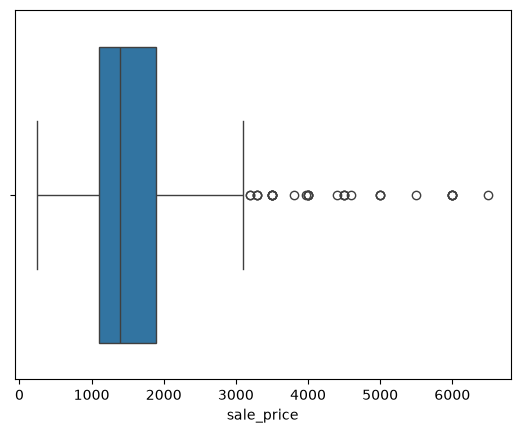

In [311]:
sns.boxplot(data=df,x='sale_price')

In [48]:
df[df['sale_price']>3000][['base_model','sale_price']]

,base_model,sale_price
61,airdopes 393 anc,3999.0
69,airdopes 441 pro,3199.0
73,airdopes 458,3299.0
77,airdopes 501 anc,3969.0
79,airdopes 601 anc,4999.0
83,airdopes 711,4999.0
204,airdopes pulse,5990.0
216,immortal 1300,3499.0
236,rockerz 355,3099.0
251,rockerz plus 450 anc,3099.0


In [49]:
fig = px.box(
    df,
    y='sale_price',
    points='outliers',
    title='Sale Price Distribution and Outliers'
)

fig.update_layout(
    width=900,
    height=600,
    yaxis_title='Sale Price (₹)',
    xaxis_title=''
)

fig.show()

In [123]:
wireless_df = df[
    ~df['category'].isin(['Wired Headphones', 'Wired Earphones'])
].copy()

fig = px.box(
    wireless_df,
    y='playback_per_charge',
    points='outliers',
    title='Playback per Charge: Outlier Analysis'
)

fig.update_layout(
    yaxis_title='Playback per Charge (Hours)',
    width=800,
    height=600
)

fig.show()

In [61]:
df[df['playback_per_charge']>50][['model_series','playback_per_charge']]

,model_series,playback_per_charge
230,Rockerz,60.0
234,Rockerz,60.0
235,Rockerz,60.0
239,Rockerz,60.0
240,Rockerz,60.0
241,Rockerz,60.0
245,Rockerz,80.0
247,Rockerz,60.0
248,Rockerz,60.0
250,Rockerz,60.0


In [57]:
pd.set_option('display.max_rows',None)

In [64]:
wireless_df = df[
    ~df['category'].isin(['Wired Headphones', 'Wired Earphones'])
].copy()

fig = px.box(
    wireless_df,
    y='playtime',
    points='outliers',
    title='Playtime: Outlier Analysis'
)

fig.update_layout(
    yaxis_title='Playtime (Hours)',
    width=800,
    height=600
)

fig.show()

In [124]:
df.to_csv('final_i.csv')

In [127]:
brand_counts = df['brand'].value_counts()

fig = px.pie(
    values=brand_counts.values,
    names=brand_counts.index,
    title='Product Distribution by Brand',
    hole=0.35
)

fig.update_traces(
    textinfo='percent+label',
    textposition='inside'
)

fig.update_layout(
    width=800,
    height=550
)

fig.show()

In [129]:

fig = px.violin(
    df,
    x='price_tier',
    y='rating',
    color='brand',
    box=True,
    points=False,
    hover_data=['base_model'],
    category_orders={
        'price_tier': ['Budget', 'Mid', 'High']
    },
    title='Product Ratings Across Price Tiers'
)

fig.update_traces(
    meanline_visible=True,
    jitter=0.25,
    pointpos=0
)

fig.update_layout(
    xaxis_title='Price Tier',
    yaxis_title='Rating',
    yaxis=dict(range=[3.5, 5.1]),
    width=1000,
    height=600
)

fig.show()

In [130]:
import plotly.express as px

# TWS only
tws_df = df[
    df['category']=='True Wireless Earbuds'
].copy()

# Median playback by brand and price tier
playback_tier = (
    tws_df
    .groupby(['price_tier', 'brand'], as_index=False)['playback_per_charge']
    .median()
)

# Correct price-tier order
tier_order = ['Budget', 'Mid', 'High']
playback_tier['price_tier'] = pd.Categorical(
    playback_tier['price_tier'],
    categories=tier_order,
    ordered=True
)

playback_tier = playback_tier.sort_values('price_tier')

fig = px.line(
    playback_tier,
    x='price_tier',
    y='playback_per_charge',
    color='brand',
    markers=True,
    text='playback_per_charge',
    title='Median Playback Time by Brand and Price Tier'
)

fig.update_traces(
    texttemplate='%{text:.1f} hrs',
    textposition='top center',
    line=dict(width=3),
    marker=dict(size=9)
)

fig.update_layout(
    xaxis_title='Price Tier',
    yaxis_title='Median Playback Time (hours)',
    yaxis=dict(range=[0, 12]),
    width=1000,
    height=600
)

fig.show()

In [131]:
fig = px.scatter(
    tws_df,
    x='battery_capacity',
    y='playback_per_charge',
    color='brand',
    hover_data=['base_model'],
    title='Battery Capacity vs Playback per Charge'
)

fig.update_layout(
    xaxis_title='Battery Capacity (mAh)',
    yaxis_title='Playback per Charge (hours)'
)

fig.show()

In [141]:
dfv=df.copy()

In [139]:
pd.set_option('display.max_columns',None)

In [150]:
dfv.drop(columns=['product_id'],inplace=True)

In [152]:
dfv[dfv.duplicated()]

,brand,category,sale_price,mrp,discount_percent,num_variants,edition_type,model_series,year,month,color_count,driver_size_mm,playback_per_charge,bluetooth,has_anc,has_enc,playtime,latency,fast_charge,connectivity,gaming_mode,battery_capacity,base_model,price_tier
2,boAt,Headphones,1799.0,3990.0,54.91,1.0,Franchise,Rockerz,2021.0,12.0,1.0,40.0,15.0,4.2,False,False,15.0,45.0,False,Dual,False,300.0,rockerz 450,Mid
21,boAt,True Wireless Earbuds,1099.0,2990.0,63.24,1.0,Franchise,Airdopes,2022.0,6.0,1.0,13.0,3.0,5.0,False,False,12.0,50.0,False,Single,False,650.0,airdopes 131,Budget
490,boAt,Headphones,999.0,3990.0,74.96,1.0,Franchise,Rockerz,2022.0,6.0,1.0,40.0,15.0,4.2,False,False,15.0,40.0,False,Single,False,300.0,rockerz 450,Budget


In [149]:
dfv.loc[[1,2]]

,brand,category,sale_price,mrp,discount_percent,num_variants,edition_type,model_series,year,month,color_count,driver_size_mm,product_id,playback_per_charge,bluetooth,has_anc,has_enc,playtime,latency,fast_charge,connectivity,gaming_mode,battery_capacity,base_model,price_tier
1,boAt,Headphones,1799.0,3990.0,54.91,1.0,Franchise,Rockerz,2021.0,12.0,1.0,40.0,6.632403e+12,15.0,4.2,False,False,15.0,45.0,False,Dual,False,300.0,rockerz 450,Mid
2,boAt,Headphones,1799.0,3990.0,54.91,1.0,Franchise,Rockerz,2021.0,12.0,1.0,40.0,6.632403e+12,15.0,4.2,False,False,15.0,45.0,False,Dual,False,300.0,rockerz 450,Mid


In [156]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# boAt Airdopes
airdopes = df[
    df['model_series'].str.strip().str.lower() == 'airdopes'
].copy()

# Noise Air Buds
air_buds = df[
    (df['brand'].str.lower() == 'noise') &
    (df['base_model'].str.contains('air buds', case=False, na=False))
].copy()

print("Airdopes:", len(airdopes))
print("Air Buds:", len(air_buds))

Airdopes: 164
Air Buds: 13


In [155]:
df.drop(index=21,inplace=True)

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


airdopes = df[
    df['model_series'].str.strip().str.lower() == 'airdopes'
].copy()

air_buds = df[
    (df['brand'].str.strip().str.lower() == 'noise') &
    (df['base_model'].str.contains('air buds', case=False, na=False))
].copy()

print("Airdopes:", len(airdopes))
print("Air Buds:", len(air_buds))



metrics = {
    'Driver Size': 'driver_size_mm',
    'Case Battery Capacity': 'battery_capacity',
    'Claimed Playback': 'playback_per_charge',
    'Rating': 'rating'
}

airdopes_values = [
    airdopes[col].median()
    for col in metrics.values()
]

air_buds_values = [
    air_buds[col].median()
    for col in metrics.values()
]



fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=list(metrics.keys()),
    horizontal_spacing=0.12,
    vertical_spacing=0.18
)



positions = [
    (1, 1),
    (1, 2),
    (2, 1),
    (2, 2)
]

for i, ((title, column), (row, col_pos)) in enumerate(
    zip(metrics.items(), positions)
):

    fig.add_trace(
        go.Scatter(
            x=['Airdopes', 'Air Buds'],
            y=[
                airdopes_values[i],
                air_buds_values[i]
            ],
            mode='lines+markers+text',

            text=[
                f'{airdopes_values[i]:.1f}',
                f'{air_buds_values[i]:.1f}'
            ],

            textposition='top center',

            marker=dict(
                size=10
            ),

            line=dict(
                width=2
            ),

            showlegend=False
        ),
        row=row,
        col=col_pos
    )



fig.update_yaxes(
    title_text='mm',
    range=[0, 15],
    row=1,
    col=1
)

fig.update_yaxes(
    title_text='mAh',
    range=[0, 500],
    row=1,
    col=2
)

fig.update_yaxes(
    title_text='Hours',
    range=[0, 10],
    row=2,
    col=1
)

fig.update_yaxes(
    title_text='Rating',
    range=[4.6, 5.0],
    row=2,
    col=2
)



fig.update_xaxes(
    title_text='Product Family',
    row=1,
    col=1
)

fig.update_xaxes(
    title_text='Product Family',
    row=1,
    col=2
)

fig.update_xaxes(
    title_text='Product Family',
    row=2,
    col=1
)

fig.update_xaxes(
    title_text='Product Family',
    row=2,
    col=2
)



fig.update_layout(
    title='Airdopes vs Air Buds: Product Characteristics',

    width=1100,
    height=750,

    margin=dict(
        t=100,
        l=80,
        r=60,
        b=80
    )
)

fig.show()

Airdopes: 164
Air Buds: 13


In [ ]:

rating_data = (
    df.groupby(['category', 'brand'], as_index=False)['rating']
      .mean()
)

fig = px.line(
    rating_data,
    x='category',
    y='rating',
    color='brand',
    markers=True,
    text='rating',
    title='Mean Rating by Brand and Category'
)

fig.for_each_trace(
    lambda trace: trace.update(
        textposition='top center'
        if trace.name == 'Noise'
        else 'bottom center'
    )
)

fig.update_traces(
    texttemplate='%{text:.2f}'
)

fig.update_layout(
    xaxis_title='Product Category',
    yaxis_title='Mean Rating',
    yaxis=dict(range=[4, 5.1]),
    width=1100,
    height=600
)

fig.show()

In [163]:
df[df['has_anc']==True & df['anc_db'].isna()]['base_model']

55      airdopes 311 pro
322      air clips 2 ows
324    air clips pro ows
428            view buds
Name: base_model, dtype: str

In [165]:
df.loc[[322,324],'has_anc']=False

In [166]:
df.loc[[55,428],'anc_db']=[32,32]

<Axes: xlabel='anc_db', ylabel='Density'>

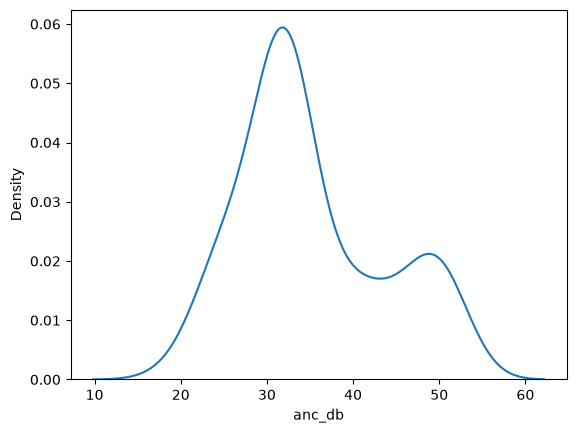

In [167]:
sns.kdeplot(data=df,x='anc_db')

In [168]:
gaming = (
    df.groupby(['price_tier', 'brand'])['gaming_mode']
      .mean()
      .mul(100)
      .reset_index()
)

fig = px.line(
    gaming,
    x='price_tier',
    y='gaming_mode',
    color='brand',
    markers=True,
    text=gaming['gaming_mode'].round(1).astype(str) + '%',
    title='Gaming Mode Adoption by Brand and Price Tier'
)

fig.update_traces(
    textposition='top center',
    textfont_size=12
)

fig.update_layout(
    xaxis_title='Price Tier',
    yaxis_title='Products with Gaming Mode (%)',
    yaxis=dict(range=[0, 55]),
    width=1100,
    height=650
)

fig.show()

In [169]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=['Budget', 'Mid', 'High'],
    y=[11.4, 38.9, 69.2],
    mode='lines+markers+text',
    name='Noise - ANC',
    text=['11.4%', '38.9%', '69.2%'],
    textposition='top center'
))

fig.add_trace(go.Scatter(
    x=['Budget', 'Mid', 'High'],
    y=[7.3, 20.1, 60.9],
    mode='lines+markers+text',
    name='boAt - ANC',
    text=['7.3%', '20.1%', '60.9%'],
    textposition='bottom center'
))

fig.add_trace(go.Scatter(
    x=['Budget', 'Mid', 'High'],
    y=[62.0, 69.4, 38.5],
    mode='lines+markers+text',
    name='Noise - ENC',
    text=['62.0%', '69.4%', '38.5%'],
    textposition='top center'
))

fig.add_trace(go.Scatter(
    x=['Budget', 'Mid', 'High'],
    y=[49.4, 50.7, 52.2],
    mode='lines+markers+text',
    name='boAt - ENC',
    text=['49.4%', '50.7%', '52.2%'],
    textposition='bottom center'
))

fig.update_layout(
    title='ANC and ENC Adoption by Brand and Price Tier',
    xaxis_title='Price Tier',
    yaxis_title='Product Adoption (%)',
    yaxis=dict(range=[0, 80]),
    hovermode='x unified',
    template='plotly_white',
    width=1000,
    height=600
)

fig.show()

In [170]:
df.groupby('price_tier')['sale_price'].agg(['min', 'max', 'count'])

,min,max,count
price_tier,,,
Budget,249.0,1499.0,311
High,3099.0,6499.0,36
Mid,1599.0,2999.0,170
